# LoFTR Left–Forward Sidewalk Matching

Match a **left-looking** streetview image against a **forward-looking** image of the same sidewalk using LoFTR.

**Key idea:** A left-looking camera sees the sidewalk as a horizontal band (depth = across the image x-axis).  
Rotating it **90° counter-clockwise** converts it to the same orientation as a forward image (sidewalk as a vertical trapezoid),  
so the existing `find_row_edges` + `rectify_sidewalk` pipeline can be applied directly.  
After rectification both images share the same coordinate system (x = sidewalk width, y = depth/travel direction),  
so no additional flip is needed before LoFTR — unlike the forward/backward case.

## 1. Imports

In [48]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import kornia as K
import kornia.feature as KF
from dotenv import load_dotenv
from google.cloud import storage

device = torch.device('mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('device:', device)

device: mps


## 2. Configuration

Set `IMAGE_NAME_FORWARD` and `IMAGE_NAME_LEFT` to your image blob paths.  
Sidewalk masks are auto-discovered from GCS under `v3/segmentation-results/{id}_{lat}_{lon}/{direction}/sidewalk/`.

In [49]:
load_dotenv(os.path.join('..', '.env'))
GCS_BUCKET_NAME = os.environ.get('GCS_BUCKET_NAME', '')
GCP_PROJECT_ID  = os.environ.get('GCP_PROJECT_ID', '')

# --- Replace with your image pair ---
IMAGE_NAME_FORWARD = "streetview/polygon_4v/20260404T133859Z/013-0258_forward_40.9730953_29.0653181_305.0.jpg"
IMAGE_NAME_LEFT    = "streetview/polygon_4v/20260404T133859Z/013-0258_left_40.9730953_29.0653181_215.0.jpg"

def masks_prefix_for(image_name: str) -> str:
    fn = os.path.basename(image_name)
    img_id, direction, lat, lon, _ = fn.replace('.jpg', '').split('_')
    return f"v3/segmentation-results/{img_id[4:8]}_{lat}_{lon}/{direction}"

MASKS_PREFIX_FORWARD = masks_prefix_for(IMAGE_NAME_FORWARD)
MASKS_PREFIX_LEFT    = masks_prefix_for(IMAGE_NAME_LEFT)
print('Forward masks prefix:', MASKS_PREFIX_FORWARD)
print('Left    masks prefix:', MASKS_PREFIX_LEFT)

# --- LoFTR parameters ---
HFOV_DEG             = 90       # horizontal field of view (degrees) — same for all cameras
LOFTR_WEIGHTS        = 'outdoor'
LOFTR_LONG_SIDE      = 840
MIN_CONFIDENCE       = 0.5
RESTRICT_TO_SIDEWALK = True

# --- Crop parameters ---
# Matching overlap is at the BOTTOM of the rectified forward image (near/adjacent part)
# and the BOTTOM of the rectified left image (the ahead/far part ends up at the bottom
# of the left image after CCW rotation + rectification).
# CROP_FWD_BOTTOM_RATIO : fraction of rectified forward to keep (counted from the bottom)
# CROP_LEFT_TOP_RATIO   : fraction of rectified left to keep (counted from the bottom,
#                         despite the variable name — reused as the keep-fraction)
CROP_FWD_BOTTOM_RATIO  = 0.2   # keep bottom 40% of rectified forward
CROP_LEFT_TOP_RATIO    = 0.2   # keep bottom 40% of rectified left (ahead/overlap region)

Forward masks prefix: v3/segmentation-results/0258_40.9730953_29.0653181/forward
Left    masks prefix: v3/segmentation-results/0258_40.9730953_29.0653181/left


## 3. GCS Loaders

Fetching forward image...


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


  (640, 640, 3)
Fetching left image...


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


  (640, 640, 3)
Fetching sidewalk masks (forward)...


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_S

  1 valid mask(s)
    Mask 0: Side=left, Area=21,915 px
Fetching sidewalk masks (left)...


/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/talha/Library/CloudStorage/Dropbox/s8/cmpe492/cv-urban-accessibility-senior-project/.venv/lib/python3.13/site-packages/google/auth/_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_S

  1 valid mask(s)
    Mask 0: Side=left, Area=46,777 px


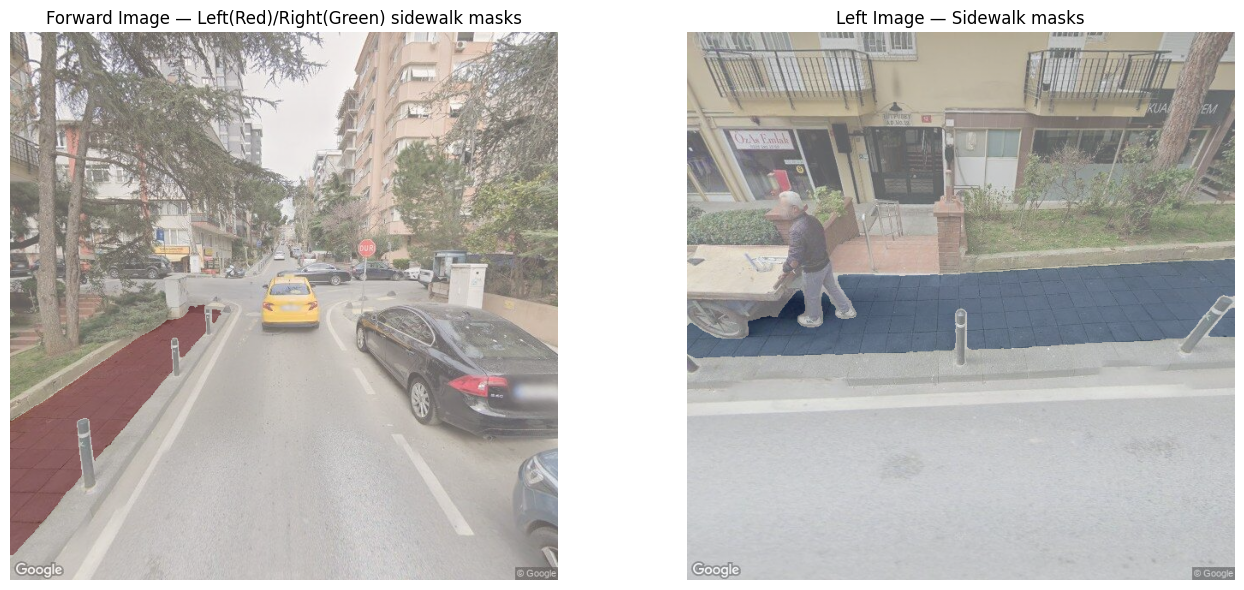

In [50]:
def _gcs_bucket():
    return storage.Client(project=GCP_PROJECT_ID).bucket(GCS_BUCKET_NAME)

def download_image_from_gcs(blob_name: str) -> np.ndarray:
    data = _gcs_bucket().blob(blob_name).download_as_bytes()
    return np.array(Image.open(io.BytesIO(data)).convert('RGB'))

def download_mask_from_gcs(blob_name: str) -> np.ndarray:
    data = _gcs_bucket().blob(blob_name).download_as_bytes()
    m = np.array(Image.open(io.BytesIO(data)).convert('L'))
    return (m > 127).astype(bool)

def list_blobs_under(prefix: str):
    return [b.name for b in _gcs_bucket().list_blobs(prefix=prefix)]

def load_individual_sidewalk_masks(masks_prefix: str, shape):
    """Load all sidewalk masks and identify their side (left/right) by center of mass."""
    blobs = [b for b in list_blobs_under(masks_prefix + '/sidewalk/') if b.endswith('.png')]
    masks = []
    W = shape[1]
    for b in blobs:
        m = download_mask_from_gcs(b)
        if m.shape != shape:
            m = cv2.resize(m.astype(np.uint8), (shape[1], shape[0]),
                           interpolation=cv2.INTER_NEAREST).astype(bool)
        cols = np.where(m.any(axis=0))[0]
        if len(cols) == 0:
            continue
        center_x = np.mean(cols)
        side = 'left' if center_x < W / 2 else 'right'
        masks.append({'mask': m, 'side': side, 'blob_name': b})
    return masks

print('Fetching forward image...')
img_forward = download_image_from_gcs(IMAGE_NAME_FORWARD)
print(f'  {img_forward.shape}')

print('Fetching left image...')
img_left = download_image_from_gcs(IMAGE_NAME_LEFT)
print(f'  {img_left.shape}')

print('Fetching sidewalk masks (forward)...')
masks_forward_list = load_individual_sidewalk_masks(MASKS_PREFIX_FORWARD, img_forward.shape[:2])
print(f'  {len(masks_forward_list)} valid mask(s)')
for i, m in enumerate(masks_forward_list):
    print(f"    Mask {i}: Side={m['side']}, Area={m['mask'].sum():,} px")

print('Fetching sidewalk masks (left)...')
masks_left_list = load_individual_sidewalk_masks(MASKS_PREFIX_LEFT, img_left.shape[:2])
print(f'  {len(masks_left_list)} valid mask(s)')
for i, m in enumerate(masks_left_list):
    print(f"    Mask {i}: Side={m['side']}, Area={m['mask'].sum():,} px")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_forward)
for m in masks_forward_list:
    axes[0].imshow(m['mask'], alpha=0.4, cmap='Reds' if m['side'] == 'left' else 'Greens')
axes[0].set_title('Forward Image — Left(Red)/Right(Green) sidewalk masks')
axes[0].axis('off')

axes[1].imshow(img_left)
for m in masks_left_list:
    axes[1].imshow(m['mask'], alpha=0.4, cmap='Blues')
axes[1].set_title('Left Image — Sidewalk masks')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. LoFTR Model Setup

In [51]:
def to_loftr_tensor(img_rgb: np.ndarray, long_side: int):
    """Return (gray tensor [1,1,H',W'] in [0,1], scale_x, scale_y) where scale maps resized->original."""
    H, W = img_rgb.shape[:2]
    s = long_side / max(H, W)
    newW, newH = int(round(W * s)), int(round(H * s))
    newW -= newW % 8
    newH -= newH % 8
    newW = max(8, newW)
    newH = max(8, newH)
    img_resized = cv2.resize(img_rgb, (newW, newH), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    t = torch.from_numpy(gray).float()[None, None] / 255.0
    return t, W / newW, H / newH

def stack_side_by_side(a, b):
    h = max(a.shape[0], b.shape[0])
    pad = lambda x: np.pad(x, ((0, h - x.shape[0]), (0, 0), (0, 0)))
    return np.concatenate([pad(a), pad(b)], axis=1), a.shape[1]

print('Loading LoFTR weights:', LOFTR_WEIGHTS)
matcher = KF.LoFTR(pretrained=LOFTR_WEIGHTS).eval().to(device)

Loading LoFTR weights: outdoor


## 5. Rectification Utilities

Copied verbatim from `loftr_common_point.ipynb` (originally from `sidewalk_measurement.ipynb`).

In [52]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

BORDER_MARGIN             = 3
RANSAC_RESIDUAL_THRESHOLD = 1.0
RANSAC_MIN_SAMPLES        = 0.3
SHIFT_PERCENTILE          = 10
ROAD_TOUCH_MARGIN         = 20
ROAD_CONFIRMED_WEIGHT     = 5.0


def find_row_edges(mask: np.ndarray, road_mask: np.ndarray = None,
                   border_margin: int = BORDER_MARGIN,
                   ransac_threshold: float = RANSAC_RESIDUAL_THRESHOLD,
                   ransac_min_samples: float = RANSAC_MIN_SAMPLES,
                   road_touch_margin: int = ROAD_TOUCH_MARGIN):
    sw_center = np.mean(np.where(mask.any(axis=0))[0])
    if road_mask is not None and np.any(road_mask):
        road_center = np.mean(np.where(road_mask.any(axis=0))[0])
        is_left_sidewalk = sw_center < road_center
    else:
        is_left_sidewalk = None

    H, W = mask.shape
    left_edges  = np.full(H, np.nan)
    right_edges = np.full(H, np.nan)
    valid       = np.zeros(H, dtype=bool)
    extrapolated = np.zeros(H, dtype=bool)

    left_valid   = np.zeros(H, dtype=bool)
    right_valid  = np.zeros(H, dtype=bool)
    left_clipped  = np.zeros(H, dtype=bool)
    right_clipped = np.zeros(H, dtype=bool)
    has_sidewalk  = np.zeros(H, dtype=bool)

    road_confirmed_L = np.zeros(H, dtype=bool)
    road_confirmed_R = np.zeros(H, dtype=bool)

    for r in range(H):
        cols = np.where(mask[r])[0]
        if len(cols) == 0:
            continue
        has_sidewalk[r] = True
        left_col  = cols[0]
        right_col = cols[-1]
        left_edges[r]  = left_col
        right_edges[r] = right_col

        left_at_border  = left_col  < border_margin
        right_at_border = right_col >= W - border_margin

        if not left_at_border:
            left_valid[r] = True
        else:
            left_clipped[r] = True

        if not right_at_border:
            right_valid[r] = True
        else:
            right_clipped[r] = True

        if road_mask is not None and is_left_sidewalk is not None:
            road_cols = np.where(road_mask[r])[0]
            if len(road_cols) > 0:
                if is_left_sidewalk:
                    dist_right = np.min(np.abs(road_cols - right_col))
                    if dist_right <= road_touch_margin:
                        road_confirmed_R[r] = True
                        right_valid[r]  = True
                        right_clipped[r] = False
                    else:
                        right_valid[r] = False
                else:
                    dist_left = np.min(np.abs(road_cols - left_col))
                    if dist_left <= road_touch_margin:
                        road_confirmed_L[r] = True
                        left_valid[r]  = True
                        left_clipped[r] = False
                    else:
                        left_valid[r] = False

    both_valid      = left_valid & right_valid
    left_valid_idx  = np.where(left_valid)[0]
    right_valid_idx = np.where(right_valid)[0]

    n_rc_L = road_confirmed_L[left_valid_idx].sum()  if len(left_valid_idx)  > 0 else 0
    n_rc_R = road_confirmed_R[right_valid_idx].sum() if len(right_valid_idx) > 0 else 0
    print(f"    Road-confirmed edges — left: {n_rc_L}, right: {n_rc_R}")

    edge_model = None

    if len(left_valid_idx) >= 2 and len(right_valid_idx) >= 2:
        a_L, b_L, inlier_mask_L = _fit_edge(
            left_valid_idx, left_edges, road_confirmed_L, side='left',
            ransac_threshold=ransac_threshold, ransac_min_samples=ransac_min_samples)
        a_R, b_R, inlier_mask_R = _fit_edge(
            right_valid_idx, right_edges, road_confirmed_R, side='right',
            ransac_threshold=ransac_threshold, ransac_min_samples=ransac_min_samples)

        edge_model = {
            'a_L': a_L, 'b_L': b_L,
            'a_R': a_R, 'b_R': b_R,
            'inlier_mask_L': inlier_mask_L,
            'inlier_mask_R': inlier_mask_R,
            'left_valid_idx':  left_valid_idx,
            'right_valid_idx': right_valid_idx,
            'valid_idx': np.where(both_valid)[0],
            'road_confirmed_L': road_confirmed_L,
            'road_confirmed_R': road_confirmed_R,
        }

        for r in np.where(has_sidewalk)[0]:
            if left_clipped[r]:
                left_edges[r] = a_L * r + b_L
            if right_clipped[r]:
                right_edges[r] = a_R * r + b_R
            if left_clipped[r] or right_clipped[r]:
                extrapolated[r] = True

        valid = has_sidewalk.copy()
    else:
        valid = both_valid.copy()

    return left_edges, right_edges, valid, extrapolated, edge_model


def _fit_edge(valid_idx, edges, road_confirmed, side='left',
              ransac_threshold=RANSAC_RESIDUAL_THRESHOLD,
              ransac_min_samples=RANSAC_MIN_SAMPLES):
    rc_mask = road_confirmed[valid_idx]
    n_rc    = rc_mask.sum()
    rc_rows = valid_idx[rc_mask]
    is_left = (side == 'left')

    if n_rc >= 4:
        a, b = np.polyfit(rc_rows.astype(float), edges[rc_rows], 1)
        fitted_rc    = a * rc_rows.astype(float) + b
        residuals_rc = edges[rc_rows] - fitted_rc
        shift = np.percentile(residuals_rc, SHIFT_PERCENTILE if is_left else 100 - SHIFT_PERCENTILE)
        b += shift

        fitted_all    = a * valid_idx.astype(float) + b
        residuals_all = edges[valid_idx] - fitted_all
        inlier_mask = (residuals_all < ransac_threshold) if is_left else (residuals_all > -ransac_threshold)
        inlier_mask[rc_mask] = True

        if inlier_mask.sum() >= 2:
            clean_idx = valid_idx[inlier_mask]
            weights = np.ones(len(clean_idx), dtype=float)
            for i, r in enumerate(clean_idx):
                if road_confirmed[r]:
                    weights[i] = ROAD_CONFIRMED_WEIGHT
            a, b = np.polyfit(clean_idx.astype(float), edges[clean_idx], 1, w=weights)
            fitted2     = a * rc_rows.astype(float) + b
            residuals2  = edges[rc_rows] - fitted2
            shift = np.percentile(residuals2, SHIFT_PERCENTILE if is_left else 100 - SHIFT_PERCENTILE)
            b += shift
            fitted3     = a * valid_idx.astype(float) + b
            residuals3  = edges[valid_idx] - fitted3
            inlier_mask = (residuals3 < ransac_threshold) if is_left else (residuals3 > -ransac_threshold)
            inlier_mask[rc_mask] = True

        print(f"    {side.capitalize()} edge: road-confirmed fit ({n_rc} anchor rows, {inlier_mask.sum()} total inliers)")
        return a, b, inlier_mask

    if len(valid_idx) >= 4:
        X = valid_idx.reshape(-1, 1).astype(float)
        sample_weights = np.ones(len(valid_idx), dtype=float)
        if n_rc > 0:
            sample_weights[rc_mask] = ROAD_CONFIRMED_WEIGHT
        ransac = RANSACRegressor(estimator=LinearRegression(),
                                 residual_threshold=ransac_threshold,
                                 min_samples=ransac_min_samples,
                                 random_state=42)
        ransac.fit(X, edges[valid_idx], sample_weight=sample_weights)
        a = ransac.estimator_.coef_[0]
        b = ransac.estimator_.intercept_

        fitted    = a * valid_idx.astype(float) + b
        residuals = edges[valid_idx] - fitted
        inlier_mask = (residuals < ransac_threshold) if is_left else (residuals > -ransac_threshold)
        if n_rc > 0:
            inlier_mask[rc_mask] = True

        if inlier_mask.sum() >= 2:
            clean_idx = valid_idx[inlier_mask]
            weights = np.ones(len(clean_idx), dtype=float)
            for i, r in enumerate(clean_idx):
                if road_confirmed[r]:
                    weights[i] = ROAD_CONFIRMED_WEIGHT
            a, b = np.polyfit(clean_idx.astype(float), edges[clean_idx], 1, w=weights)
            fitted2         = a * clean_idx.astype(float) + b
            residuals_clean = edges[clean_idx] - fitted2
            shift = np.percentile(residuals_clean, SHIFT_PERCENTILE if is_left else 100 - SHIFT_PERCENTILE)
            b += shift
            fitted3     = a * valid_idx.astype(float) + b
            residuals3  = edges[valid_idx] - fitted3
            inlier_mask = (residuals3 < ransac_threshold) if is_left else (residuals3 > -ransac_threshold)
            if n_rc > 0:
                inlier_mask[rc_mask] = True
    else:
        a, b = np.polyfit(valid_idx.astype(float), edges[valid_idx], 1)
        inlier_mask = np.ones(len(valid_idx), dtype=bool)

    return a, b, inlier_mask


def rectify_sidewalk(image_or_mask, left_edges, right_edges, valid_rows,
                     edge_model=None, target_width=None, is_mask=False,
                     cos_correction=1.0, f_px=None):
    H, W = image_or_mask.shape[:2]
    cy   = H / 2.0

    valid_widths = right_edges[valid_rows] - left_edges[valid_rows]
    if len(valid_widths) == 0:
        return image_or_mask, target_width or 100, 0
    if target_width is None:
        target_width = int(np.median(valid_widths) * cos_correction)

    valid_idx = np.where(valid_rows)[0]
    all_rows  = np.arange(H)
    left_interp  = np.full(H, np.nan)
    right_interp = np.full(H, np.nan)

    if len(valid_idx) < 2:
        left_interp[:]  = left_edges[valid_idx[0]]  if len(valid_idx) else 0
        right_interp[:] = right_edges[valid_idx[0]] if len(valid_idx) else W - 1
        vy = -1e8
        first_valid = 0
        last_valid  = H - 1
        a_L, b_L = 0.0, left_interp[0]
        a_R, b_R = 0.0, right_interp[0]
    else:
        if edge_model is not None:
            a_L, b_L = edge_model['a_L'], edge_model['b_L']
            a_R, b_R = edge_model['a_R'], edge_model['b_R']
        else:
            valid_r = valid_idx.astype(float)
            a_L, b_L = np.polyfit(valid_r, left_edges[valid_idx], 1)
            a_R, b_R = np.polyfit(valid_r, right_edges[valid_idx], 1)

        left_interp  = a_L * all_rows + b_L
        right_interp = a_R * all_rows + b_R

        vy = (b_R - b_L) / (a_L - a_R) if abs(a_L - a_R) > 1e-6 else -1e8
        first_valid = valid_idx[0]
        last_valid  = valid_idx[-1]

    use_perp  = False
    vp_perp_x = 0.0
    if f_px is not None and abs(a_L - a_R) > 1e-6:
        vp_x        = a_L * vy + b_L
        vp_x_offset = vp_x - W / 2.0
        if abs(vp_x_offset) > 1e-6:
            a_avg = (a_L + a_R) / 2.0
            sign  = 1.0 if a_avg > 0 else -1.0
            vp_perp_x = W / 2.0 + sign * f_px * f_px / abs(vp_x_offset)
            use_perp  = True

    row_scale = np.ones(H, dtype=np.float64)
    ref_dist  = abs(last_valid - vy)
    MAX_STRETCH = 50.0

    for r in range(first_valid, last_valid + 1):
        dist = abs(r - vy)
        row_scale[r] = min((ref_dist / dist) ** 2 if dist > 0 else MAX_STRETCH, MAX_STRETCH)

    cum_real = np.cumsum(row_scale)
    cum_real = cum_real - cum_real[0]
    out_height = int(np.ceil(cum_real[-1])) + 1
    out_rows   = np.arange(out_height, dtype=np.float32)
    src_row_for_out = np.interp(out_rows, cum_real, np.arange(H, dtype=np.float32))

    padding   = int(target_width * 0.3)
    out_width = target_width + 2 * padding

    map_x = np.zeros((out_height, out_width), dtype=np.float32)
    map_y = np.zeros((out_height, out_width), dtype=np.float32)
    out_cols = np.arange(out_width, dtype=np.float32)

    for out_r in range(out_height):
        src_r     = src_row_for_out[out_r]
        src_r_int = int(src_r)
        L = left_interp[min(src_r_int, H - 1)]
        R = right_interp[min(src_r_int, H - 1)]
        src_r_frac = src_r - src_r_int
        if src_r_frac > 0 and src_r_int + 1 < H:
            L = L * (1 - src_r_frac) + left_interp[src_r_int + 1]  * src_r_frac
            R = R * (1 - src_r_frac) + right_interp[src_r_int + 1] * src_r_frac

        src_width = R - L
        if src_width <= 0:
            map_x[out_r, :] = -1
            map_y[out_r, :] = src_r
            continue

        cx = (L + R) / 2.0

        if use_perp and src_r > cy + 1:
            dx_perp = vp_perp_x - cx
            if abs(dx_perp) > 1e-6:
                perp_slope = (cy - src_r) / dx_perp
                denom_L = 1.0 - a_L * perp_slope
                denom_R = 1.0 - a_R * perp_slope
                if abs(denom_L) > 1e-9 and abs(denom_R) > 1e-9:
                    t_L = (L - cx) / denom_L
                    t_R = (R - cx) / denom_R
                    perp_span = t_R - t_L
                    if perp_span > 0:
                        t = t_L + (out_cols - padding) / target_width * perp_span
                        map_x[out_r, :] = cx + t
                        map_y[out_r, :] = src_r + t * perp_slope
                        continue

        scale = src_width / target_width
        map_x[out_r, :] = L + (out_cols - padding) * scale
        map_y[out_r, :] = src_r

    flags  = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    inp    = image_or_mask.astype(np.uint8) if is_mask else image_or_mask
    warped = cv2.remap(inp, map_x, map_y, interpolation=flags, borderMode=cv2.BORDER_CONSTANT)
    if is_mask:
        warped = warped.astype(bool)
    return warped, target_width, padding

## 5. Left-Side Inverse Perspective Mapping (IPM) Unrolling

In [53]:
def rectify_left_ipm(image, single_mask, target_width=None, is_mask=False):
    """
    Rectify the side-facing (90-degree) view by unrolling the "distortion from the middle"
    and rotating it to match the forward-facing orthographic view.
    
    The resulting image has:
    - Width = target_width (across the sidewalk, building-side on the left)
    - Height = Original image width (along the sidewalk, far-ahead at the top)
    """
    H, W = image.shape[:2]
    
    # We map the horizontal span of the side image directly to the vertical span of the output
    H_out = W
    # The output width matches the forward image's sidewalk width
    W_out = int(target_width) if target_width else 100
    
    if not single_mask.any():
        return (np.zeros((H_out, W_out), dtype=bool), W_out) if is_mask else (np.zeros((H_out, W_out, 3), dtype=image.dtype), W_out)

    # 1. Find top and bottom mask boundaries per column
    col_tops = np.full(W, -1, dtype=float)
    col_bots = np.full(W, -1, dtype=float)
    
    y_coords, x_coords = np.where(single_mask)
    if len(x_coords) == 0:
        return (np.zeros((H_out, W_out), dtype=bool), W_out) if is_mask else (np.zeros((H_out, W_out, 3), dtype=image.dtype), W_out)
        
    for x in range(W):
        mask_col_y = y_coords[x_coords == x]
        if len(mask_col_y) > 0:
            col_tops[x] = mask_col_y.min()
            col_bots[x] = mask_col_y.max()
            
    # Interpolate missing columns
    valid_cols = np.where(col_bots >= 0)[0]
    if len(valid_cols) == 0:
        return (np.zeros((H_out, W_out), dtype=bool), W_out) if is_mask else (np.zeros((H_out, W_out, 3), dtype=image.dtype), W_out)
        
    col_tops = np.interp(np.arange(W), valid_cols, col_tops[valid_cols])
    col_bots = np.interp(np.arange(W), valid_cols, col_bots[valid_cols])
    
    # Smooth the boundaries slightly to prevent jaggedness
    col_tops = cv2.GaussianBlur(col_tops.reshape(1, W), (1, 31), 0).flatten()
    col_bots = cv2.GaussianBlur(col_bots.reshape(1, W), (1, 31), 0).flatten()

    # Create coordinate maps for cv2.remap (shape: H_out, W_out)
    U_out, V_out = np.meshgrid(np.arange(W_out), np.arange(H_out))
    
    # In output, v=0 is top (far ahead), v=H_out-1 is bottom (near behind).
    # In left image, x=W-1 is far right (ahead), x=0 is far left (behind).
    X_orig = (W - 1) - V_out.astype(np.float32)
    
    # For each pixel, get the interpolated top/bottom for its X_orig
    X_orig_clipped = np.clip(X_orig, 0, W - 1).astype(int)
    tops_mapped = col_tops[X_orig_clipped]
    bots_mapped = col_bots[X_orig_clipped]
    
    # U_out maps from 0 (Left/Building) to W_out-1 (Right/Street).
    # tops_mapped is Building, bots_mapped is Street.
    U_frac = U_out.astype(np.float32) / max(W_out - 1, 1)
    Y_orig = tops_mapped + U_frac * (bots_mapped - tops_mapped)
    
    map_x = X_orig
    map_y = Y_orig.astype(np.float32)
    
    flags = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    inp = image.astype(np.uint8) if is_mask else image
    warped = cv2.remap(inp, map_x, map_y, interpolation=flags, borderMode=cv2.BORDER_CONSTANT)
    
    return (warped.astype(bool), W_out) if is_mask else (warped, W_out)

## 6. Debug Visualization

Verify both rectifications before running LoFTR.

- **Forward:** standard 3-panel (original + edges | rectified image | rectified mask).
- **Left:** 4-panel — original | rotated 90° CCW + detected edges | rectified image | rectified mask.

In [54]:
def _compute_rectify_params(img, model, original_width=None):
    if original_width is None:
        original_width = img.shape[1]
    f_px = original_width / (2.0 * np.tan(np.radians(HFOV_DEG / 2.0)))
    if model is not None:
        denom = model['a_L'] - model['a_R']
        vp_y  = (model['b_R'] - model['b_L']) / denom if abs(denom) > 1e-6 else 0
        vp_x  = model['a_L'] * vp_y + model['b_L']
        cos_corr = np.cos(max(0.0, np.arctan((vp_x - img.shape[1] / 2.0) / f_px)))
    else:
        cos_corr = 1.0
    return f_px, cos_corr


def visualize_rectification_forward(img, mask_item, title_prefix='Forward'):
    single_mask = mask_item['mask']
    side        = mask_item['side']

    left, right, valid, extrap, model = find_row_edges(single_mask)
    f_px, cos_corr = _compute_rectify_params(img, model)
    rect_img,  w, pad = rectify_sidewalk(img, left, right, valid, edge_model=model,
                                         f_px=f_px, cos_correction=cos_corr)
    rect_mask, _, _   = rectify_sidewalk(single_mask, left, right, valid, edge_model=model,
                                         target_width=w, is_mask=True,
                                         f_px=f_px, cos_correction=cos_corr)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(img)
    axes[0].imshow(single_mask, cmap='Blues', alpha=0.3)
    if model is not None:
        y_vals = np.arange(img.shape[0])
        axes[0].plot(model['a_L'] * y_vals + model['b_L'], y_vals,
                     color='red',  linewidth=2, label='Left edge')
        axes[0].plot(model['a_R'] * y_vals + model['b_R'], y_vals,
                     color='lime', linewidth=2, label='Right edge')
        axes[0].legend(loc='lower right')
    axes[0].set_title(f"{title_prefix} \u2014 {side.capitalize()} sidewalk")
    axes[0].axis('off')
    axes[1].imshow(rect_img)
    axes[1].set_title('Rectified Image')
    axes[1].axis('off')
    axes[2].imshow(rect_mask, cmap='Blues')
    axes[2].set_title('Rectified Mask')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()


def visualize_rectification_left(img, mask_item, title_prefix='Left'):
    single_mask = mask_item['mask']
    
    # We pass a typical forward target_width like 150 for visualization solely
    rect_img, w = rectify_left_ipm(img, single_mask, target_width=150)
    rect_mask, _ = rectify_left_ipm(single_mask, single_mask, target_width=w, is_mask=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img)
    axes[0].imshow(single_mask, cmap='Blues', alpha=0.3)
    
    # Plot the top and bottom unrolling boundaries
    H, W = img.shape[:2]
    y_coords, x_coords = np.where(single_mask)
    if len(x_coords) > 10:
        col_tops = np.full(W, -1, dtype=float)
        col_bots = np.full(W, -1, dtype=float)
        for x in range(W):
            mask_col_y = y_coords[x_coords == x]
            if len(mask_col_y) > 0:
                col_tops[x] = mask_col_y.min()
                col_bots[x] = mask_col_y.max()
                
        valid_cols = np.where(col_bots >= 0)[0]
        if len(valid_cols) > 0:
            col_tops = np.interp(np.arange(W), valid_cols, col_tops[valid_cols])
            col_bots = np.interp(np.arange(W), valid_cols, col_bots[valid_cols])
            col_tops = cv2.GaussianBlur(col_tops.reshape(1, W), (1, 31), 0).flatten()
            col_bots = cv2.GaussianBlur(col_bots.reshape(1, W), (1, 31), 0).flatten()
            axes[0].plot(np.arange(W), col_tops, 'r--', linewidth=2, label='Top Edge (Building)')
            axes[0].plot(np.arange(W), col_bots, 'g--', linewidth=2, label='Bottom Edge (Street)')
            axes[0].legend(loc='lower right')

    axes[0].set_title(f"{title_prefix} — Original + Unroll Boundaries")
    axes[0].axis('off')

    axes[1].imshow(rect_img)
    axes[1].set_title('Unrolled & Aligned Image')
    axes[1].axis('off')

    axes[2].imshow(rect_mask, cmap='Blues')
    axes[2].set_title('Unrolled Mask')
    axes[2].axis('off')

    plt.tight_layout()

## 7. Run LoFTR: Forward (left-side mask) vs Left Image

**Pairing rule:** Only forward masks where `side == 'left'` are matched against the left image masks.  
Both images are matched **without** a 180° flip — their rectified coordinate systems are already aligned  
(x = sidewalk width, y = depth/travel direction, far at top).


Pair: Forward Mask 0 (left-side)  vs  Left Mask 0
    Road-confirmed edges — left: 0, right: 0


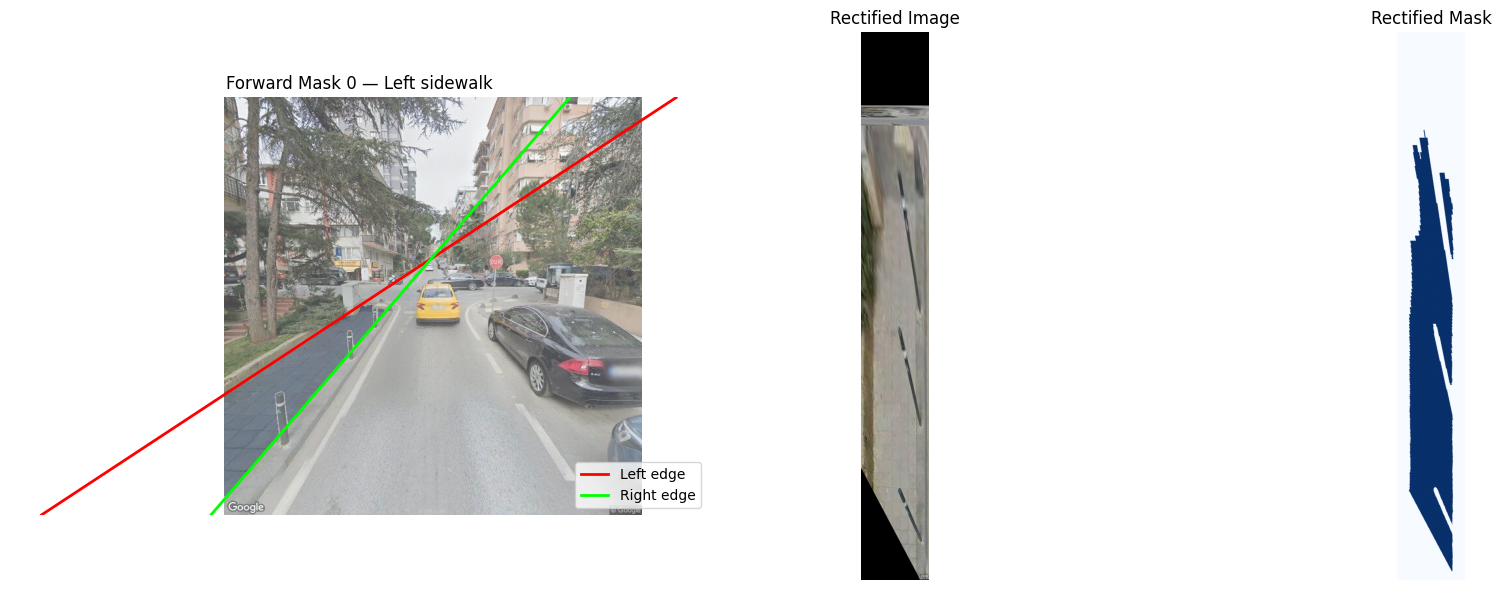

    Road-confirmed edges — left: 0, right: 0
Final valid matches: 2


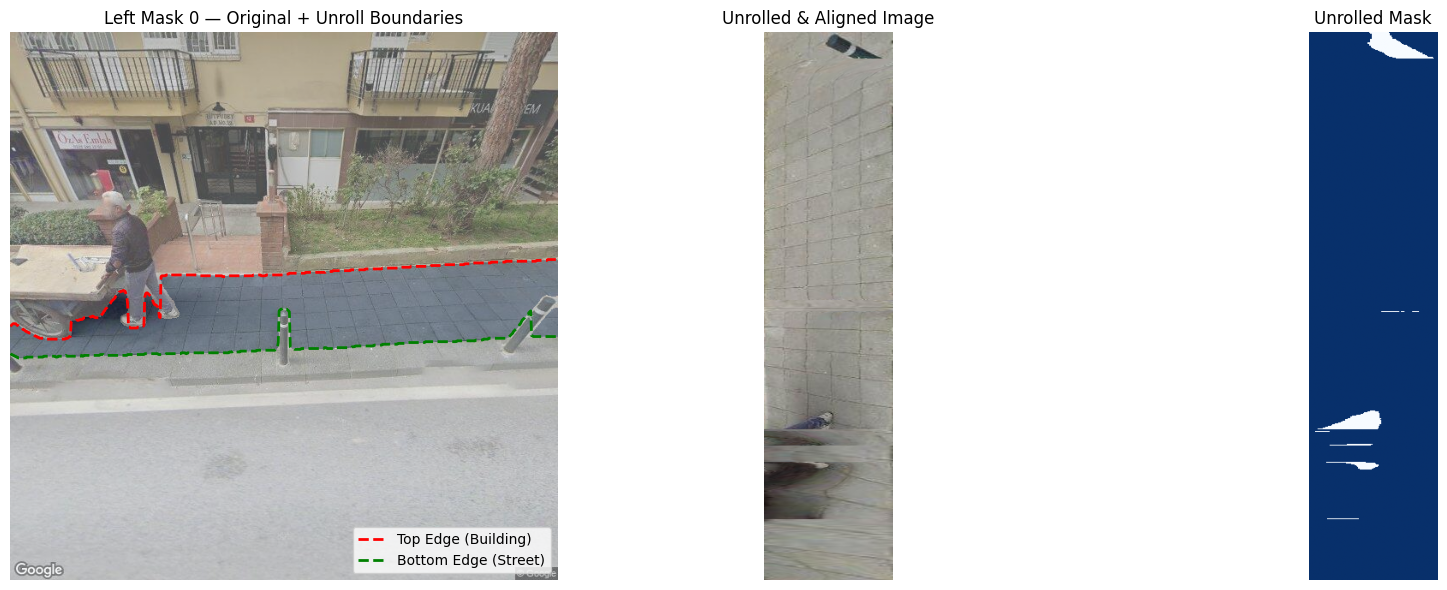

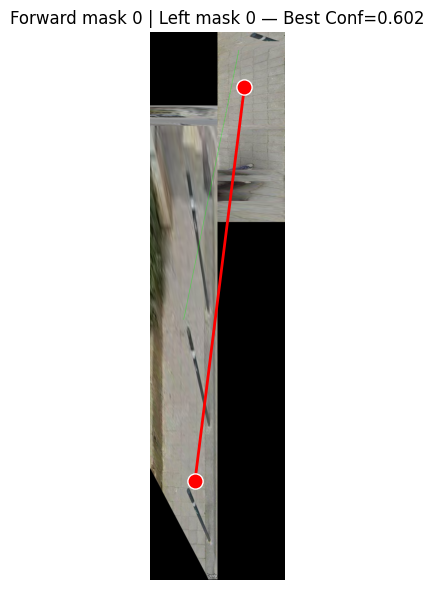



>>> BEST OVERALL MATCH: Forward Mask 0 vs Left Mask 0 — confidence 0.602 <<<



In [55]:
def _rectify_forward_mask(img, single_mask):
    left, right, valid, extrap, model = find_row_edges(single_mask)
    f_px, cos_corr = _compute_rectify_params(img, model)
    rect_img,  w, pad = rectify_sidewalk(img, left, right, valid, edge_model=model,
                                         f_px=f_px, cos_correction=cos_corr)
    rect_mask, _, _   = rectify_sidewalk(single_mask, left, right, valid, edge_model=model,
                                         target_width=w, is_mask=True,
                                         f_px=f_px, cos_correction=cos_corr)
    return rect_img, rect_mask


def _rectify_left_mask(img, single_mask, target_width):
    rect_img, w = rectify_left_ipm(img, single_mask, target_width=target_width)
    rect_mask, _ = rectify_left_ipm(single_mask, single_mask, target_width=w, is_mask=True)
    return rect_img, rect_mask


def in_mask(pts, mask):
    xs = np.clip(pts[:, 0].round().astype(int), 0, mask.shape[1] - 1)
    ys = np.clip(pts[:, 1].round().astype(int), 0, mask.shape[0] - 1)
    return mask[ys, xs]


global_best_conf = -1.0
global_best_data = None

# Show debug visualizations once per pair
for idx_fwd, mFwd in enumerate(masks_forward_list):
    if mFwd['side'] != 'left':
        continue

    for idx_left, mLeft in enumerate(masks_left_list):
        print(f"\n{'='*54}")
        print(f"Pair: Forward Mask {idx_fwd} (left-side)  vs  Left Mask {idx_left}")
        print(f"{'='*54}")

        # Show rectification debug plots before matching
        visualize_rectification_forward(img_forward, mFwd, title_prefix=f'Forward Mask {idx_fwd}')
        visualize_rectification_left(img_left, mLeft, title_prefix=f'Left Mask {idx_left}')

        rect_fwd,  rect_mask_fwd  = _rectify_forward_mask(img_forward, mFwd['mask'])
        
        # Match target_width explicitly! This guarantees both rectification outputs represent 
        # the exact same metric width scale horizontally!
        rect_left, rect_mask_left = _rectify_left_mask(img_left, mLeft['mask'], target_width=rect_fwd.shape[1])

        if rect_fwd.shape[0] < 10 or rect_left.shape[0] < 10:
            print('Rectification produced too-small image. Skipping pair.')
            continue

        # Use full rectified images — no pre-crop
        crop_fwd   = rect_fwd
        cmask_fwd  = rect_mask_fwd
        
        crop_left  = rect_left
        cmask_left = rect_mask_left

        tFwd,  sxFwd,  syFwd  = to_loftr_tensor(crop_fwd,  LOFTR_LONG_SIDE)
        tLeft, sxLeft, syLeft = to_loftr_tensor(crop_left, LOFTR_LONG_SIDE)

        with torch.inference_mode():
            out_match = matcher({'image0': tFwd.to(device), 'image1': tLeft.to(device)})

        kpts_fwd  = out_match['keypoints0'].cpu().numpy() * np.array([sxFwd,  syFwd])
        kpts_left = out_match['keypoints1'].cpu().numpy() * np.array([sxLeft, syLeft])
        conf      = out_match['confidence'].cpu().numpy()

        keep = conf >= MIN_CONFIDENCE
        if RESTRICT_TO_SIDEWALK:
            keep &= in_mask(kpts_fwd, cmask_fwd) & in_mask(kpts_left, cmask_left)

        pFwd, pLeft, pConf = kpts_fwd[keep], kpts_left[keep], conf[keep]

        if len(pFwd) >= 4:
            try:
                _, inl = cv2.findHomography(pFwd, pLeft, cv2.RANSAC, 3.0)
                if inl is not None:
                    inl = inl.ravel().astype(bool)
                    pFwd, pLeft, pConf = pFwd[inl], pLeft[inl], pConf[inl]
            except cv2.error:
                pFwd, pLeft, pConf = np.array([]), np.array([]), np.array([])

        print(f'Final valid matches: {len(pFwd)}')

        canvas, offset = stack_side_by_side(crop_fwd, crop_left)
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(canvas)

        if len(pFwd) > 0:
            best_idx  = int(np.argmax(pConf))
            best_conf = pConf[best_idx]

            if best_conf > global_best_conf:
                global_best_conf = best_conf
                global_best_data = {
                    'fwd_idx': idx_fwd, 'left_idx': idx_left,
                    'pFwd': pFwd, 'pLeft': pLeft, 'pConf': pConf,
                    'best_idx': best_idx,
                    'crop_fwd': crop_fwd, 'crop_left': crop_left,
                    'rect_fwd': rect_fwd, 'rect_left': rect_left,
                    'rect_mask_fwd': rect_mask_fwd, 'rect_mask_left': rect_mask_left,
                }

            for (xa, ya), (xb, yb) in zip(pFwd, pLeft):
                ax.plot([xa, xb + offset], [ya, yb], '-', color='lime', linewidth=0.5, alpha=0.4)

            xa, ya = pFwd[best_idx]
            xb, yb = pLeft[best_idx]
            ax.plot([xa, xb + offset], [ya, yb], '-', color='red', linewidth=2.0)
            ax.scatter([xa, xb + offset], [ya, yb], s=120, c='red', edgecolor='white', zorder=5)
            ax.set_title(f'Forward mask {idx_fwd} | Left mask {idx_left} \u2014 Best Conf={best_conf:.3f}')
        else:
            ax.set_title(f'Forward mask {idx_fwd} | Left mask {idx_left} \u2014 NO MATCHES FOUND')
            best_conf = 0.0

        ax.axis('off')
        plt.tight_layout()
        plt.show()

print("\n\n" + ">"*3 + f" BEST OVERALL MATCH: Forward Mask {global_best_data['fwd_idx']} vs Left Mask {global_best_data['left_idx']} \u2014 confidence {global_best_conf:.3f} " + "<"*3 + "\n")